The Problem & The Plan
https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

The dataset we are given is from Kaggle-- it is a real-world dataset from historical California housing data:

The data pertains to the houses found in a given California district and some summary stats about them based on the 1990 census data.

We'll take a look at this data to ultimately create a model that will predict the median home price for a given district. This will involve properly implementing the dataset into this notebook, cleaning the data and preparation for analysis, exploratory data analysis, and feature engineering. We'll then build a few models, evaluate them, and determine what insights this investigation provides.

In [54]:
# # Kaggle notebook version of import
# import warnings
# warnings.filterwarnings('ignore')
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# !pip install folium
# import folium
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [55]:
# Personal notebook import
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install folium
import folium
from folium.plugins import MarkerCluster

Data Collection

In [56]:
# Personal notebook version of loading the dataset
data=pd.read_csv("data/housing.csv")

Exploratory Data Analysis

Let's take a look at how much data there is. We'll also take a look at the columns as a starting place to see what data has been collected (or at least attempted to be collected):

In [57]:
print(data.shape)
cols = data.columns
print(cols)

(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


There are more than 20,000 individual housing groups/tracts that were included in this dataset. That's a solid number.

Looks like we've got some geographic identification in the form of latitude-longitude coordinates. We can use folium to visualize the extent of the data-- perhaps it isn't statewide. At the very least, we can see where the sampled housing sets are located.

In [58]:
long = data['longitude'].max()
lat = data['latitude'].mean()
m = folium.Map(location=[lat,long], zoom_start=6)
display(m)

In [59]:
marker_cluster = folium.plugins.MarkerCluster().add_to(m)
for idx in data.index:
    folium.Marker([data['latitude'].iloc[idx],
               data['longitude'].iloc[idx]]).add_to(marker_cluster)
display(m)

Next, let's look at some of the individual entries, and we'll also look at the basic statistical analysis and general description of the data in each category/column using head, describe, and info methods for this dataframe.

In [60]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [61]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [62]:
df.shape

(20640, 10)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Most of the data is in numeric form, all but ocean_proximity, so we'll look at how to deal with that. To start, however, let's plot the distributions (histograms) of all values to see how the numeric values are distributed.

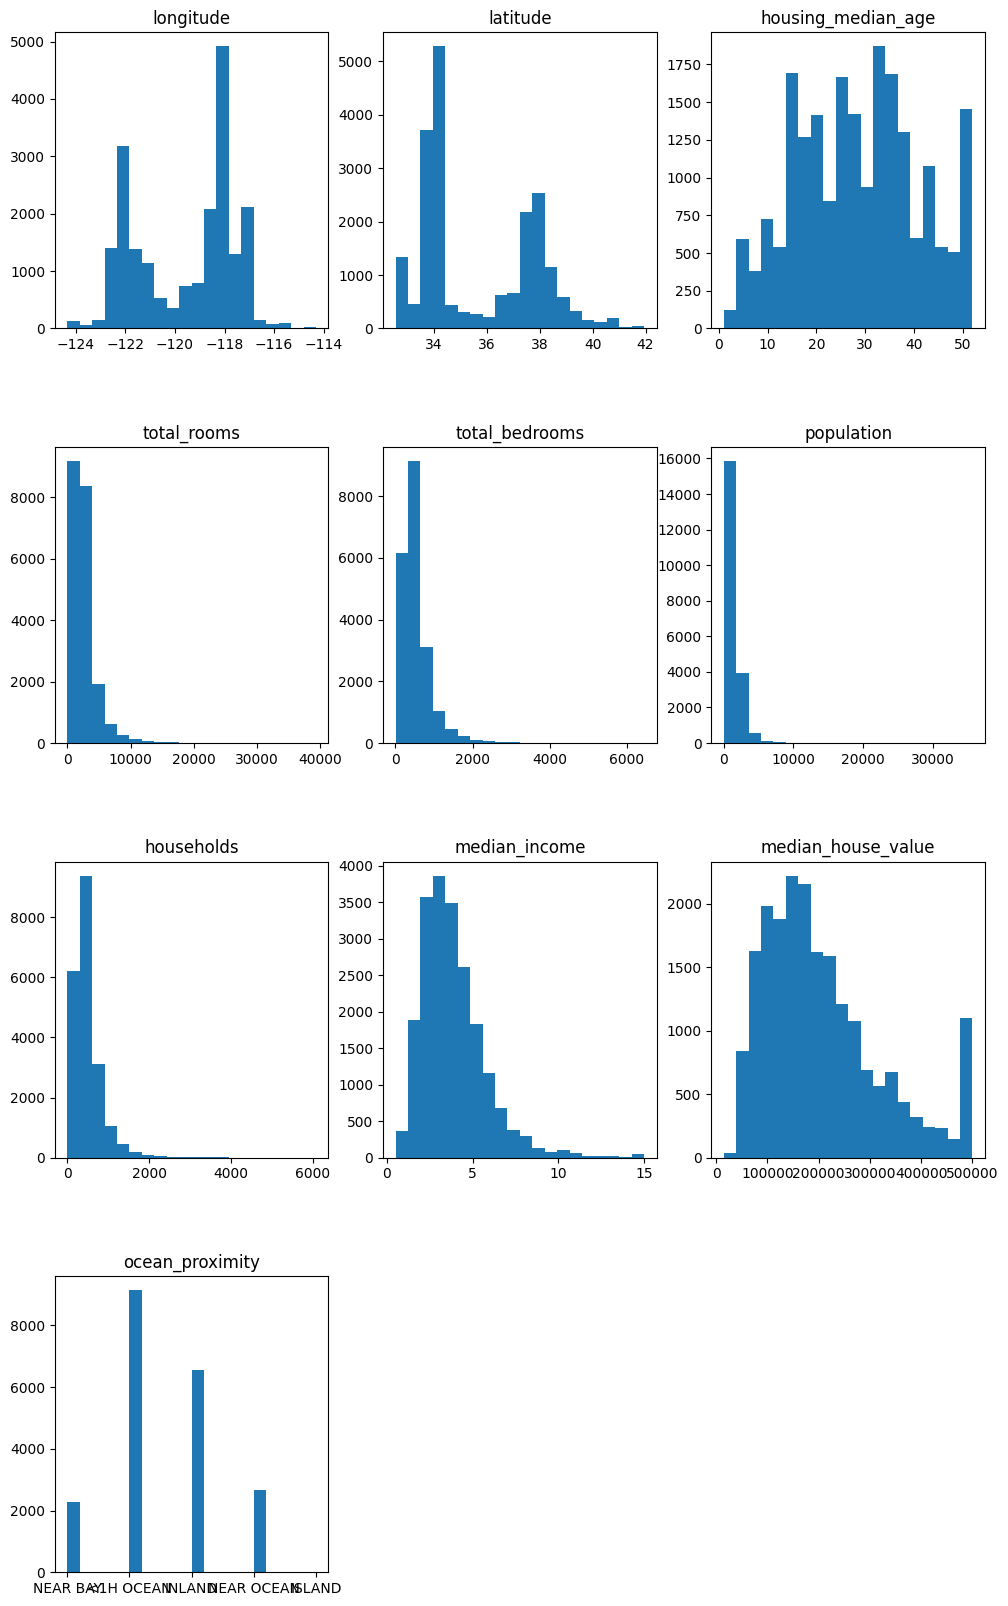

In [66]:
# Create three columns of subplots
vert_plots = 3
# Create a number of rows of subplots based on how many columns are in the dataset.
hor_plots = data.shape[1] // vert_plots
# Create the plots in a grid
if data.shape[1] % hor_plots > 0:
    hor_plots = data.shape[1] // vert_plots + 1
plt.figure(figsize=(12,20))
plt.subplots_adjust(hspace=0.4)
col_idx = 0
for vert_plot in range(vert_plots):
    for hor_plot in range(hor_plots):
        if col_idx >= len(cols):
            continue
        col = cols[col_idx]
        plt.subplot(hor_plots,vert_plots,col_idx+1)
        plt.hist(data[col], bins=20)
        col_idx += 1
        ax = plt.gca()
        ax.set_title(col)

The distributions are mixed. housing_median_age is approaching a uniform distribution. The other numeric ones are skewed to the right. We'll want to think about if/how we scale these values before building any models. Let's also look at the box plots to get a better idea of the outliers.

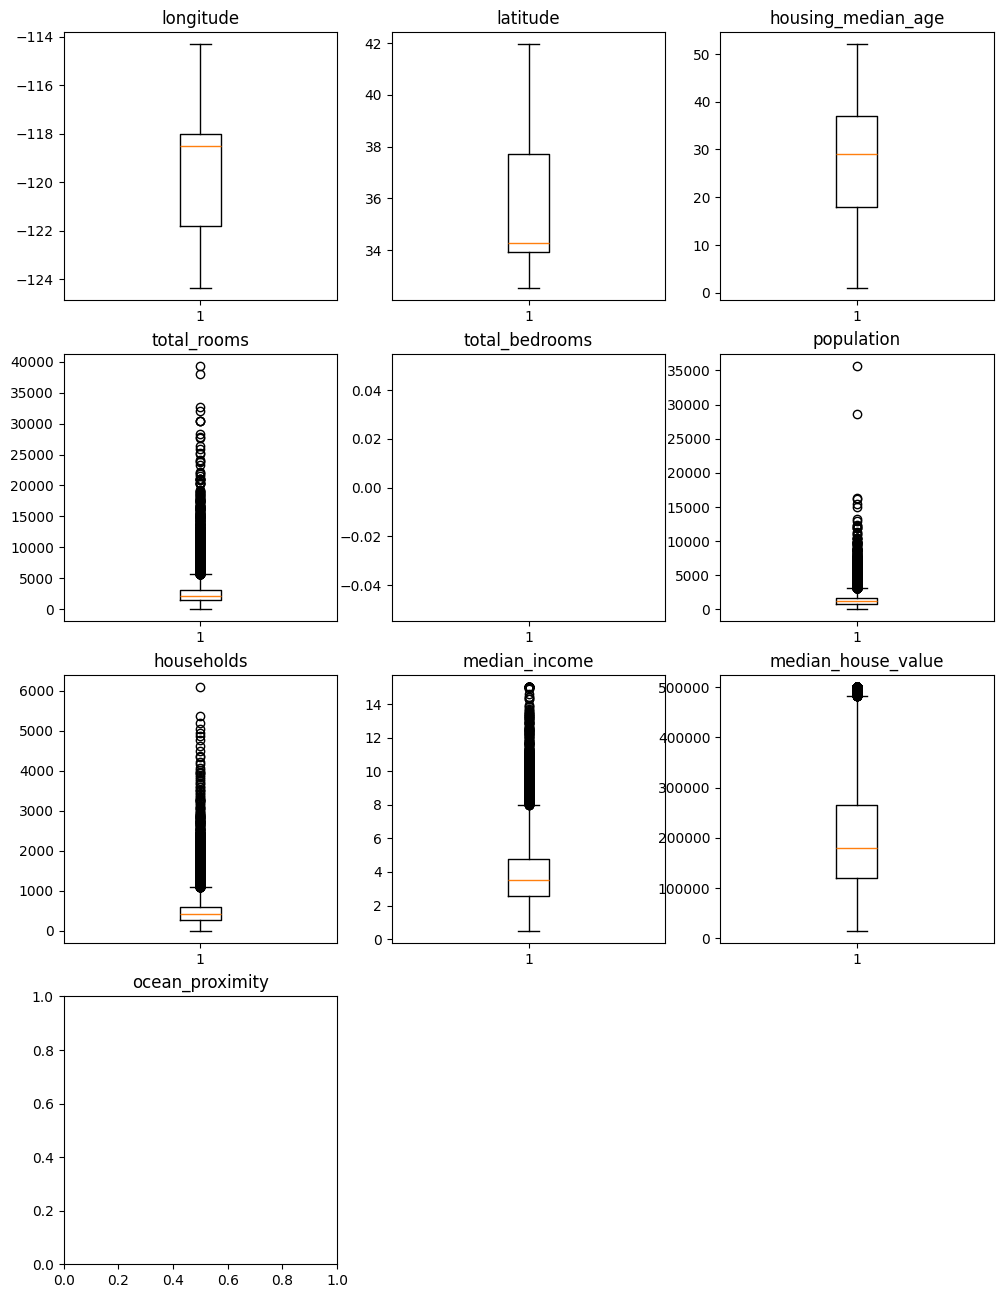

In [67]:
# Box plots, which won't include ocean proximity
vert_plots = 3
hor_plots = data.shape[1] // vert_plots
if data.shape[1] % hor_plots > 0:
    hor_plots = data.shape[1] // vert_plots + 1
plt.figure(figsize=(12,16))
plt.subplots_adjust(hspace=0.2)
col_idx = 0
for vert_plot in range(vert_plots):
    for hor_plot in range(hor_plots):
        if col_idx >= len(cols):
            continue
        col = cols[col_idx]
        plt.subplot(hor_plots,vert_plots,col_idx+1)
        try:
            plt.boxplot(data[col])
        except:
            pass
        ax = plt.gca()
        ax.set_title(col)
        col_idx += 1

Missing Values

We're missing any information on ocean_proximity due to its categorical nature, as expected, but we are also missing a box plot for total_bedrooms. This may be due to missing data; we'll check:

In [69]:
print('Total number of missing values:',data.isnull().sum())
null_rows = data[data.isnull().any(axis=1)]
data_notnull = data.drop(index=null_rows.index)

Total number of missing values: longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
